# Exploratory Data Analysis — Used Car Dynamic Pricing

This notebook explores the training dataset for the **Dynamic Pricing Optimization for Used Cars** project. We inspect structure, missing values, the target `price`, numerical and categorical features, brand/model/power distributions, outliers, and feature correlations.

**Data source:** `data/raw/used_car_train_20200313.csv`

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 项目根目录（notebook 在 notebooks/ 下时向上一级）
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "used_car_train_20200313.csv"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42

## 1. Load dataset

The raw file is **space-separated** (not comma-separated). Several fields use `-` as a missing-value placeholder.

In [2]:
df = pd.read_csv(DATA_PATH, sep=" ", na_values=["-", ""])
df.head()

,SaleID,name,regDate,model,brand,bodyType,fuelType,gearbox,power,kilometer,...,v_5,v_6,v_7,v_8,v_9,v_10,v_11,v_12,v_13,v_14
0,0,736,20040402,30.0,6,1.0,0.0,0.0,60,12.5,...,0.235676,0.101988,0.129549,0.022816,0.097462,-2.881803,2.804097,-2.420821,0.795292,0.914762
1,1,2262,20030301,40.0,1,2.0,0.0,0.0,0,15.0,...,0.264777,0.121004,0.135731,0.026597,0.020582,-4.900482,2.096338,-1.030483,-1.722674,0.245522
2,2,14874,20040403,115.0,15,1.0,0.0,0.0,163,12.5,...,0.251410,0.114912,0.165147,0.062173,0.027075,-4.846749,1.803559,1.565330,-0.832687,-0.229963
3,3,71865,19960908,109.0,10,0.0,0.0,1.0,193,15.0,...,0.274293,0.110300,0.121964,0.033395,0.000000,-4.509599,1.285940,-0.501868,-2.438353,-0.478699
4,4,111080,20120103,110.0,5,1.0,0.0,0.0,68,5.0,...,0.228036,0.073205,0.091880,0.078819,0.121534,-1.896240,0.910783,0.931110,2.834518,1.923482


## 2. Dataset shape

In [3]:
n_rows, n_cols = df.shape
print(f"Rows: {n_rows:,}")
print(f"Columns: {n_cols}")
print(f"Shape: {df.shape}")

Rows: 150,000
Columns: 31
Shape: (150000, 31)


## 3. Data types

In [4]:
dtype_df = pd.DataFrame({"dtype": df.dtypes, "non_null": df.notna().sum()})
dtype_df

,dtype,non_null
SaleID,int64,150000
name,int64,150000
regDate,int64,150000
model,float64,149999
brand,int64,150000
bodyType,float64,145494
fuelType,float64,141320
gearbox,float64,144019
power,int64,150000
kilometer,float64,150000


## 4. First 5 rows

In [5]:
df.head(5)

,SaleID,name,regDate,model,brand,bodyType,fuelType,gearbox,power,kilometer,...,v_5,v_6,v_7,v_8,v_9,v_10,v_11,v_12,v_13,v_14
0,0,736,20040402,30.0,6,1.0,0.0,0.0,60,12.5,...,0.235676,0.101988,0.129549,0.022816,0.097462,-2.881803,2.804097,-2.420821,0.795292,0.914762
1,1,2262,20030301,40.0,1,2.0,0.0,0.0,0,15.0,...,0.264777,0.121004,0.135731,0.026597,0.020582,-4.900482,2.096338,-1.030483,-1.722674,0.245522
2,2,14874,20040403,115.0,15,1.0,0.0,0.0,163,12.5,...,0.251410,0.114912,0.165147,0.062173,0.027075,-4.846749,1.803559,1.565330,-0.832687,-0.229963
3,3,71865,19960908,109.0,10,0.0,0.0,1.0,193,15.0,...,0.274293,0.110300,0.121964,0.033395,0.000000,-4.509599,1.285940,-0.501868,-2.438353,-0.478699
4,4,111080,20120103,110.0,5,1.0,0.0,0.0,68,5.0,...,0.228036,0.073205,0.091880,0.078819,0.121534,-1.896240,0.910783,0.931110,2.834518,1.923482


## 5. Missing values

We count nulls after parsing `-` as NA, and report the share of missing values per column.

In [6]:
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_df = (
    pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct})
    .query("missing_count > 0")
    .sort_values("missing_count", ascending=False)
)
print(f"Columns with any missing value: {len(missing_df)}")
missing_df

Columns with any missing value: 5


,missing_count,missing_pct
notRepairedDamage,24324,16.22
fuelType,8680,5.79
gearbox,5981,3.99
bodyType,4506,3.00
model,1,0.00


## 6. Visualize missing values

Bar chart of missing counts (only columns with gaps) and a sample-based missingness matrix for pattern inspection.

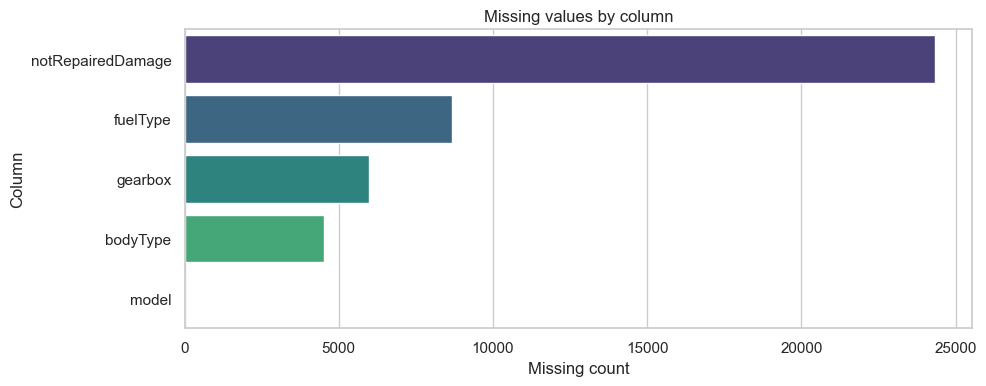

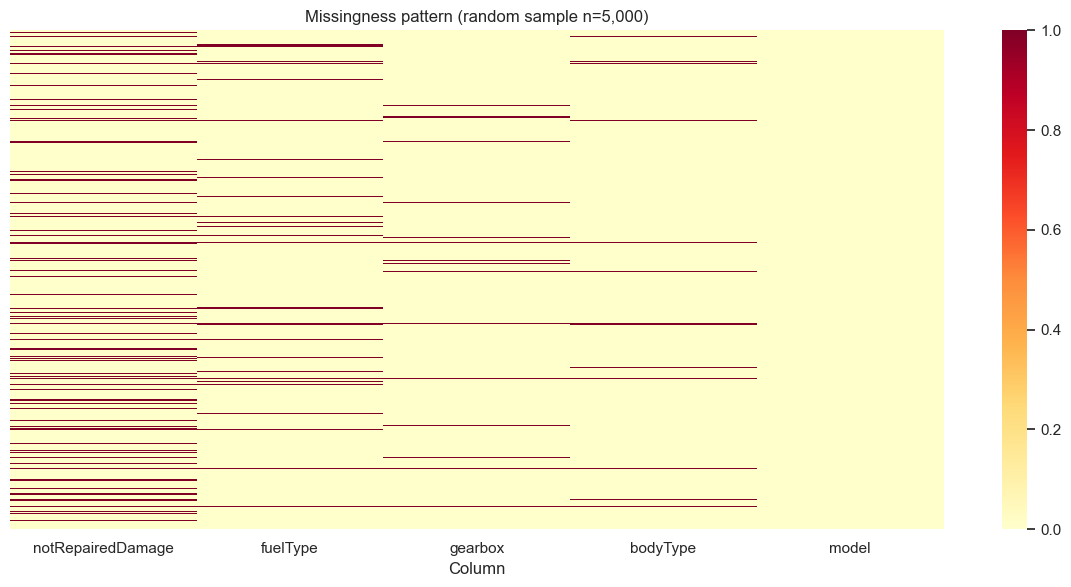

In [7]:
cols_with_missing = missing_df.index.tolist()

if cols_with_missing:
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(cols_with_missing))))
    sns.barplot(
        x=missing_df["missing_count"].values,
        y=cols_with_missing,
        hue=cols_with_missing,
        palette="viridis",
        legend=False,
        ax=ax,
    )
    ax.set_xlabel("Missing count")
    ax.set_ylabel("Column")
    ax.set_title("Missing values by column")
    plt.tight_layout()
    fig.savefig(FIG_DIR / "missing_values_bar.png", bbox_inches="tight")
    plt.show()

    sample_n = min(5000, len(df))
    sample_idx = df.sample(sample_n, random_state=RANDOM_STATE).index
    miss_sample = df.loc[sample_idx, cols_with_missing].isna()

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(
        miss_sample,
        cbar=True,
        yticklabels=False,
        cmap="YlOrRd",
        ax=ax,
    )
    ax.set_title(f"Missingness pattern (random sample n={sample_n:,})")
    ax.set_xlabel("Column")
    plt.tight_layout()
    fig.savefig(FIG_DIR / "missing_values_heatmap.png", bbox_inches="tight")
    plt.show()
else:
    print("No missing values detected after NA parsing.")

## 7. Target variable: `price`

`price` is the regression target (typical unit: RMB in this competition-style dataset). We summarize central tendency, spread, and skewness before plotting distributions.

In [8]:
price = df["price"].dropna()
price.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame("price")

,price
count,150000.000000
mean,5923.327333
std,7501.998477
min,11.000000
1%,150.000000
5%,400.000000
25%,1300.000000
50%,3250.000000
75%,7700.000000
95%,19970.000000


In [9]:
print(f"Skewness: {price.skew():.3f}")
print(f"Kurtosis: {price.kurtosis():.3f}")
print(f"Zeros: {(price == 0).sum()}")
print(f"Negative values: {(price < 0).sum()}")

Skewness: 3.346
Kurtosis: 18.995
Zeros: 0
Negative values: 0


## 8. Price distributions: histogram, KDE, boxplot

Used-car prices are usually **right-skewed**; we also show a log-scale view to highlight the bulk of listings.

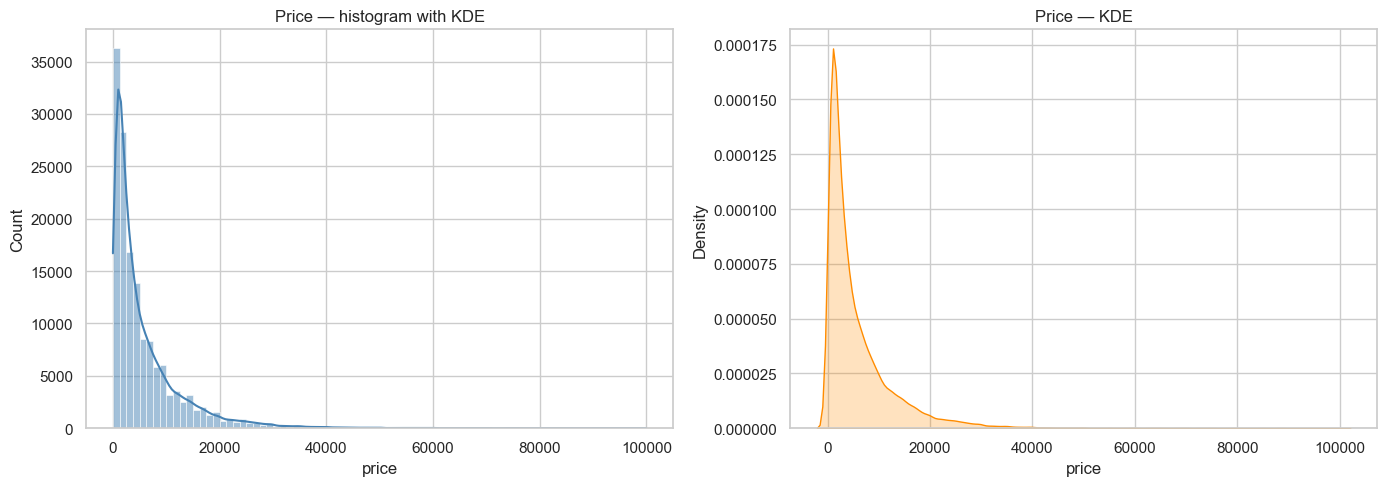

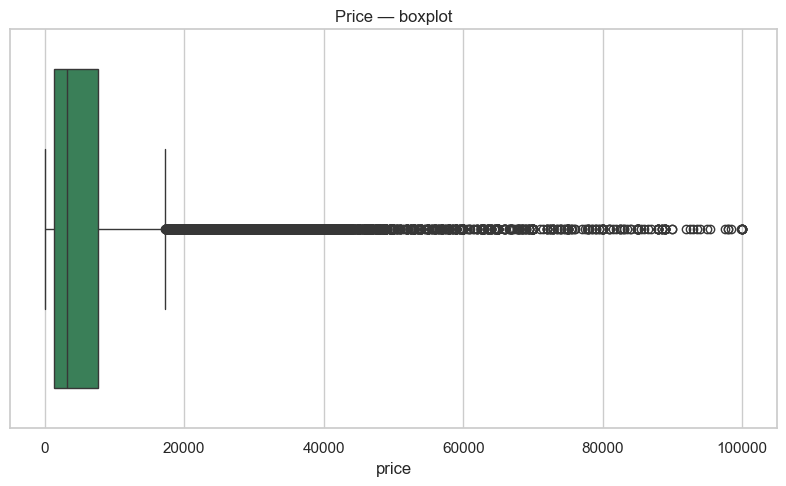

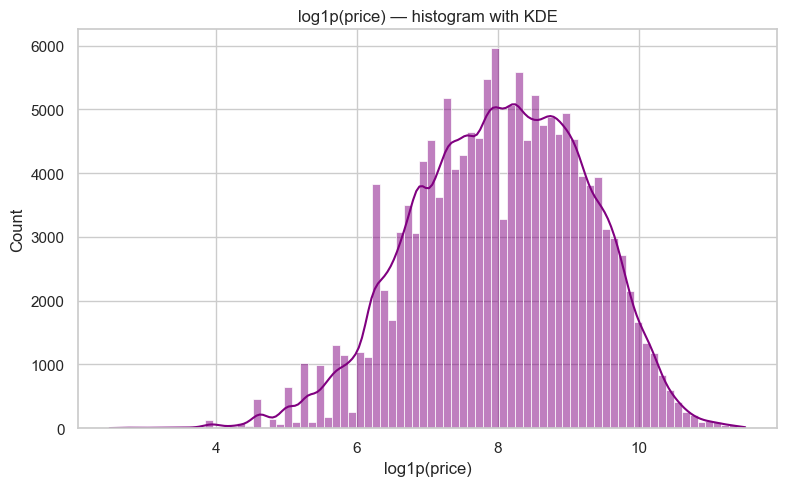

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(price, bins=80, kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("Price — histogram with KDE")
axes[0].set_xlabel("price")
axes[0].set_ylabel("Count")

sns.kdeplot(price, fill=True, color="darkorange", ax=axes[1])
axes[1].set_title("Price — KDE")
axes[1].set_xlabel("price")

plt.tight_layout()
fig.savefig(FIG_DIR / "price_hist_kde.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x=price, color="seagreen", ax=ax)
ax.set_title("Price — boxplot")
ax.set_xlabel("price")
plt.tight_layout()
fig.savefig(FIG_DIR / "price_boxplot.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(np.log1p(price), bins=80, kde=True, color="purple", ax=ax)
ax.set_title("log1p(price) — histogram with KDE")
ax.set_xlabel("log1p(price)")
plt.tight_layout()
fig.savefig(FIG_DIR / "price_log_hist_kde.png", bbox_inches="tight")
plt.show()

## Feature groups

We separate **known business fields** from anonymized `v_*` features for clearer EDA.

In [11]:
id_cols = ["SaleID", "name"]
date_cols = ["regDate", "creatDate"]
target_col = "price"
v_cols = [c for c in df.columns if c.startswith("v_")]

cat_cols = [
    "brand",
    "model",
    "bodyType",
    "fuelType",
    "gearbox",
    "notRepairedDamage",
    "seller",
    "offerType",
]
num_cols = [
    "power",
    "kilometer",
    "regionCode",
] + v_cols

print("Categorical:", cat_cols)
print("Numerical (business + v_*):", num_cols)

Categorical: ['brand', 'model', 'bodyType', 'fuelType', 'gearbox', 'notRepairedDamage', 'seller', 'offerType']
Numerical (business + v_*): ['power', 'kilometer', 'regionCode', 'v_0', 'v_1', 'v_2', 'v_3', 'v_4', 'v_5', 'v_6', 'v_7', 'v_8', 'v_9', 'v_10', 'v_11', 'v_12', 'v_13', 'v_14']


## 9. Numerical features

Summary statistics, pairwise scatter sample against `price`, and distribution plots for key numeric fields.

In [12]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
power,150000.0,119.316547,177.168419,0.000000,75.000000,110.000000,150.000000,19312.000000
kilometer,150000.0,12.597160,3.919576,0.500000,12.500000,15.000000,15.000000,15.000000
regionCode,150000.0,2583.077267,1885.363218,0.000000,1018.000000,2196.000000,3843.000000,8120.000000
v_0,150000.0,44.406268,2.457548,30.451976,43.135799,44.610266,46.004721,52.304178
v_1,150000.0,-0.044809,3.641893,-4.295589,-3.192349,-3.052671,4.000670,7.320308
v_2,150000.0,0.080765,2.929618,-4.470671,-0.970671,-0.382947,0.241335,19.035496
v_3,150000.0,0.078833,2.026514,-7.275037,-1.462580,0.099722,1.565838,9.854702
v_4,150000.0,0.017875,1.193661,-4.364565,-0.921191,-0.075910,0.868758,6.829352
v_5,150000.0,0.248204,0.045804,0.000000,0.243615,0.257798,0.265297,0.291838
v_6,150000.0,0.044923,0.051743,0.000000,0.000038,0.000812,0.102009,0.151420


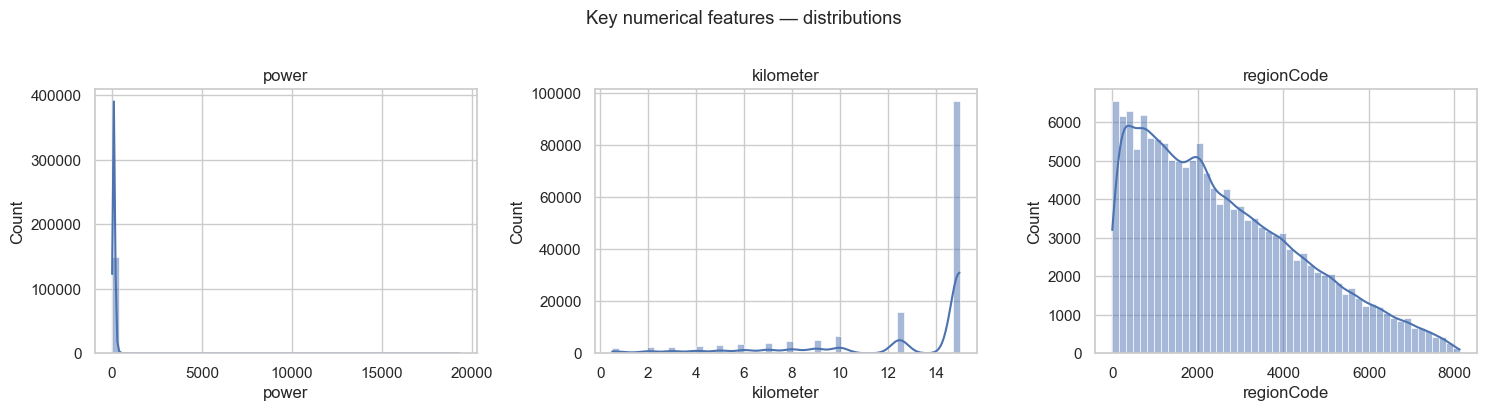

In [13]:
key_num = ["power", "kilometer", "regionCode"]
fig, axes = plt.subplots(1, len(key_num), figsize=(15, 4))
for ax, col in zip(axes, key_num):
    sns.histplot(df[col].dropna(), bins=50, kde=True, ax=ax)
    ax.set_title(col)
plt.suptitle("Key numerical features — distributions", y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / "numerical_key_distributions.png", bbox_inches="tight")
plt.show()

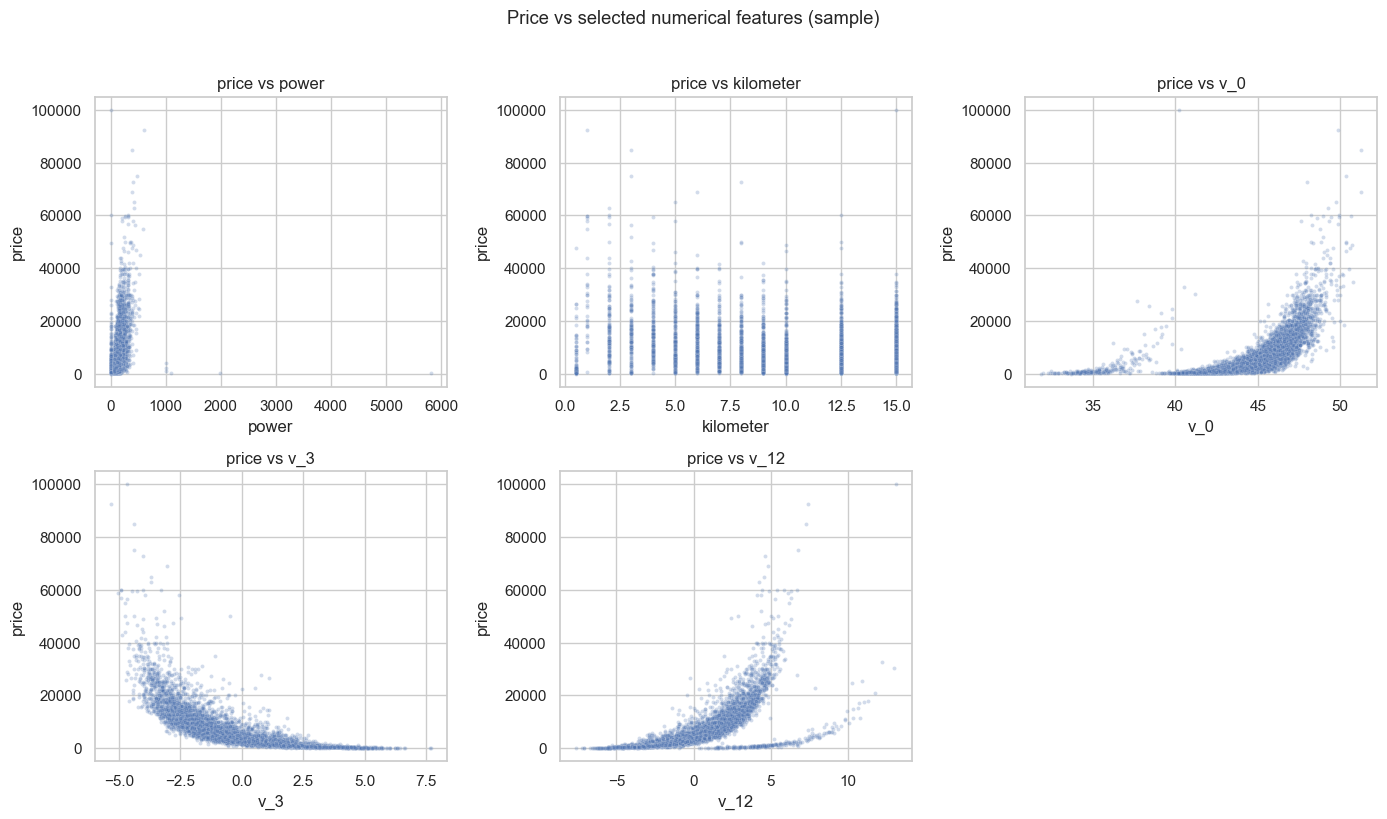

In [14]:
scatter_cols = ["power", "kilometer", "v_0", "v_3", "v_12"]
sample_plot = df[[target_col] + scatter_cols].dropna().sample(
    min(8000, len(df)), random_state=RANDOM_STATE
)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for ax, col in zip(axes, scatter_cols):
    sns.scatterplot(data=sample_plot, x=col, y=target_col, alpha=0.25, s=8, ax=ax)
    ax.set_title(f"price vs {col}")
axes[-1].axis("off")
plt.suptitle("Price vs selected numerical features (sample)", y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / "numerical_vs_price_scatter.png", bbox_inches="tight")
plt.show()

## 10. Categorical features

Cardinality, value counts, and price by category for low-cardinality fields.

In [15]:
cardinality = pd.DataFrame(
    {
        "n_unique": df[cat_cols].nunique(),
        "missing_pct": (df[cat_cols].isna().mean() * 100).round(2),
    }
).sort_values("n_unique", ascending=False)
cardinality

,n_unique,missing_pct
model,248,0.00
brand,40,0.00
bodyType,8,3.00
fuelType,7,5.79
gearbox,2,3.99
notRepairedDamage,2,16.22
seller,2,0.00
offerType,1,0.00


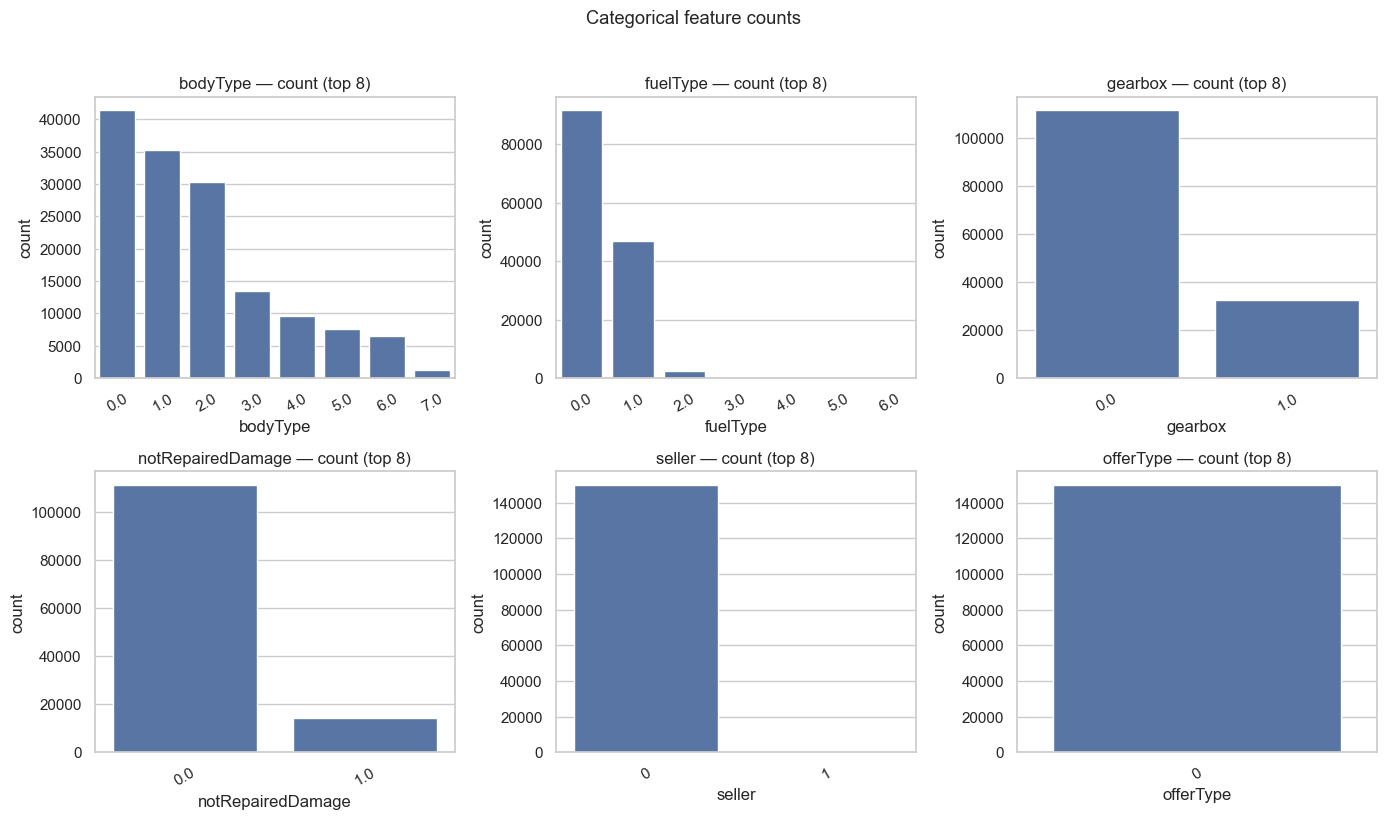

In [16]:
low_card_cat = ["bodyType", "fuelType", "gearbox", "notRepairedDamage", "seller", "offerType"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), low_card_cat):
    order = df[col].value_counts().index[:8]
    sns.countplot(data=df, x=col, order=order, ax=ax)
    ax.set_title(f"{col} — count (top 8)")
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Categorical feature counts", y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / "categorical_counts.png", bbox_inches="tight")
plt.show()

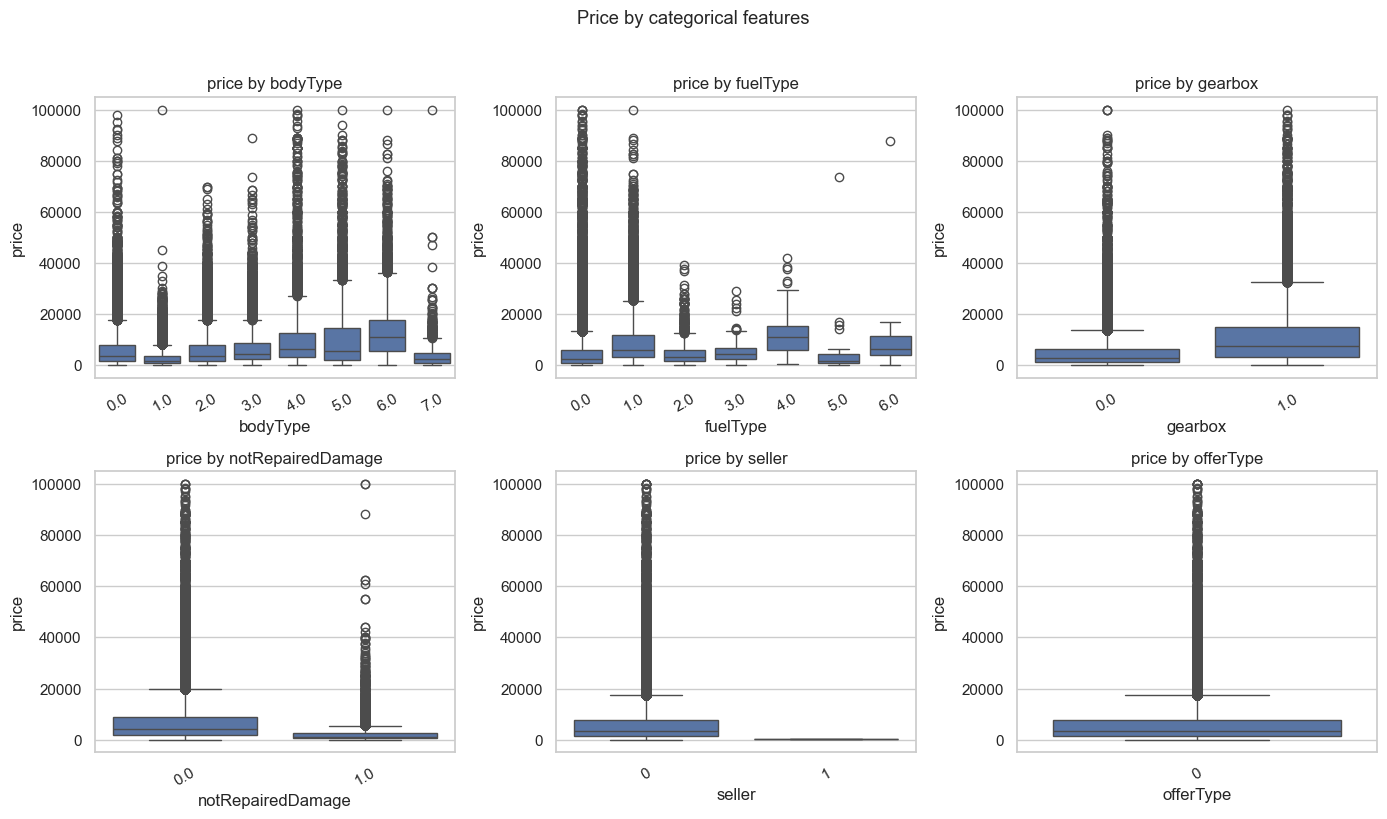

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), low_card_cat):
    sns.boxplot(data=df, x=col, y=target_col, ax=ax)
    ax.set_title(f"price by {col}")
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Price by categorical features", y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / "categorical_price_boxplot.png", bbox_inches="tight")
plt.show()

## 11. Brand distribution

`brand` is encoded as integers (0–39). We inspect frequency and median price by brand.

In [18]:
brand_counts = df["brand"].value_counts().sort_index()
brand_counts.head(10)

brand
0    31480
1    13794
2      321
3     2461
4    16737
5     4665
6    10217
7     2361
8     2077
9     7306
Name: count, dtype: int64

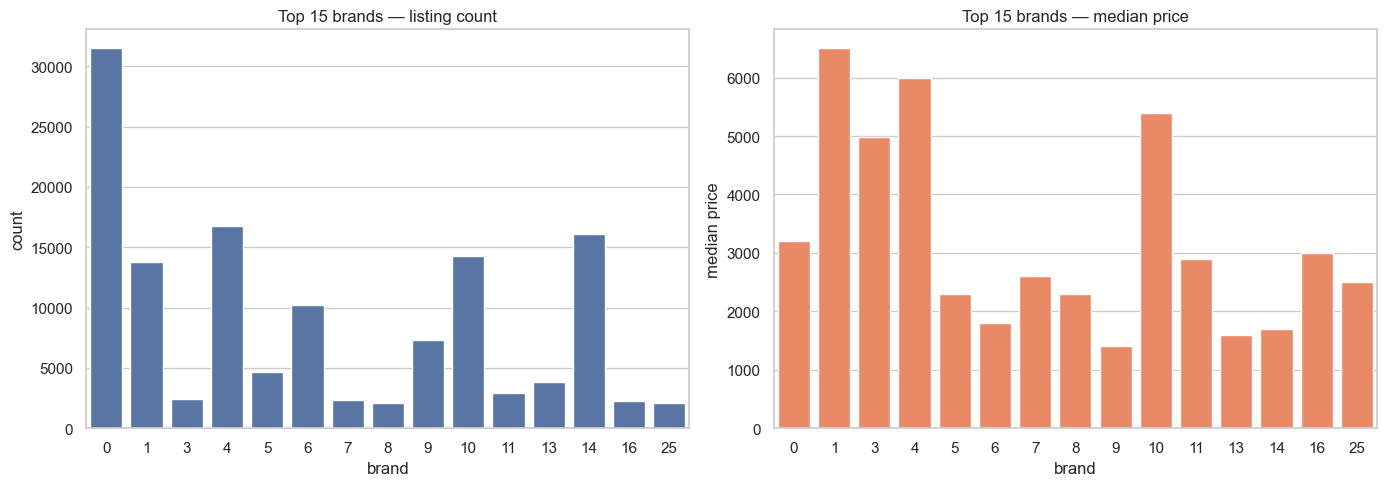

In [19]:
top_brands = df["brand"].value_counts().head(15).index
brand_plot = df[df["brand"].isin(top_brands)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=brand_plot, x="brand", order=sorted(top_brands), ax=axes[0])
axes[0].set_title("Top 15 brands — listing count")
axes[0].set_xlabel("brand")

brand_median = (
    brand_plot.groupby("brand", observed=True)["price"]
    .median()
    .reindex(sorted(top_brands))
)
sns.barplot(x=brand_median.index, y=brand_median.values, ax=axes[1], color="coral")
axes[1].set_title("Top 15 brands — median price")
axes[1].set_xlabel("brand")
axes[1].set_ylabel("median price")
plt.tight_layout()
fig.savefig(FIG_DIR / "brand_distribution.png", bbox_inches="tight")
plt.show()

## 12. Model distribution

`model` has many levels; we focus on the most frequent models and their price profiles.

In [20]:
print(f"Unique models: {df['model'].nunique():,}")
df["model"].value_counts().head(15)

Unique models: 248


model
0.0     11762
19.0     9573
4.0      8445
1.0      6038
29.0     5186
48.0     5052
40.0     4502
26.0     4496
8.0      4391
31.0     3827
13.0     3762
17.0     3121
65.0     2730
49.0     2608
46.0     2454
Name: count, dtype: int64

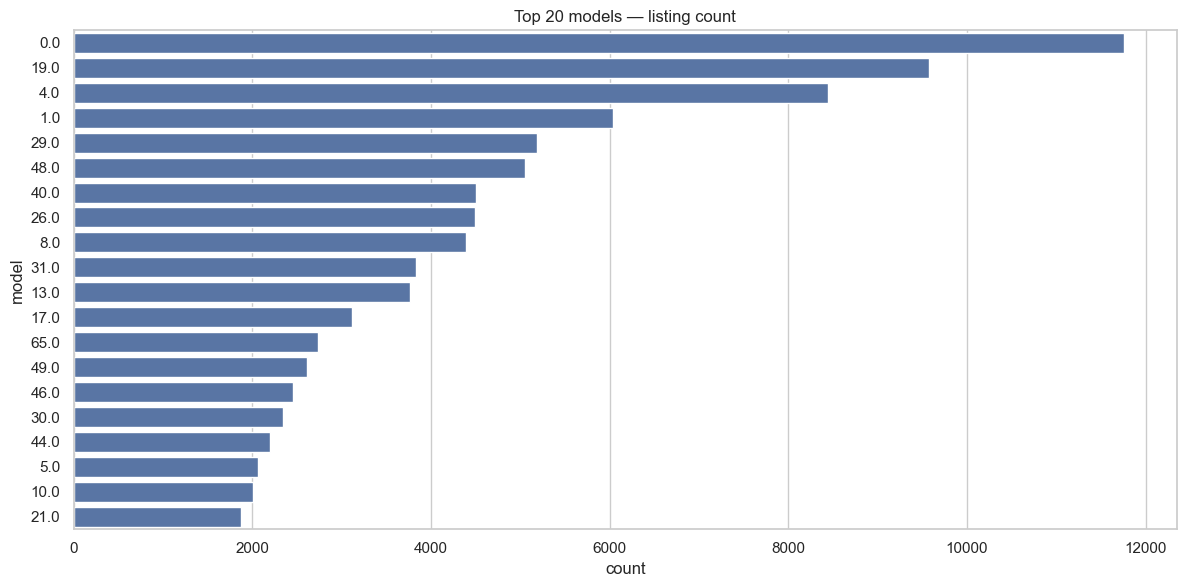

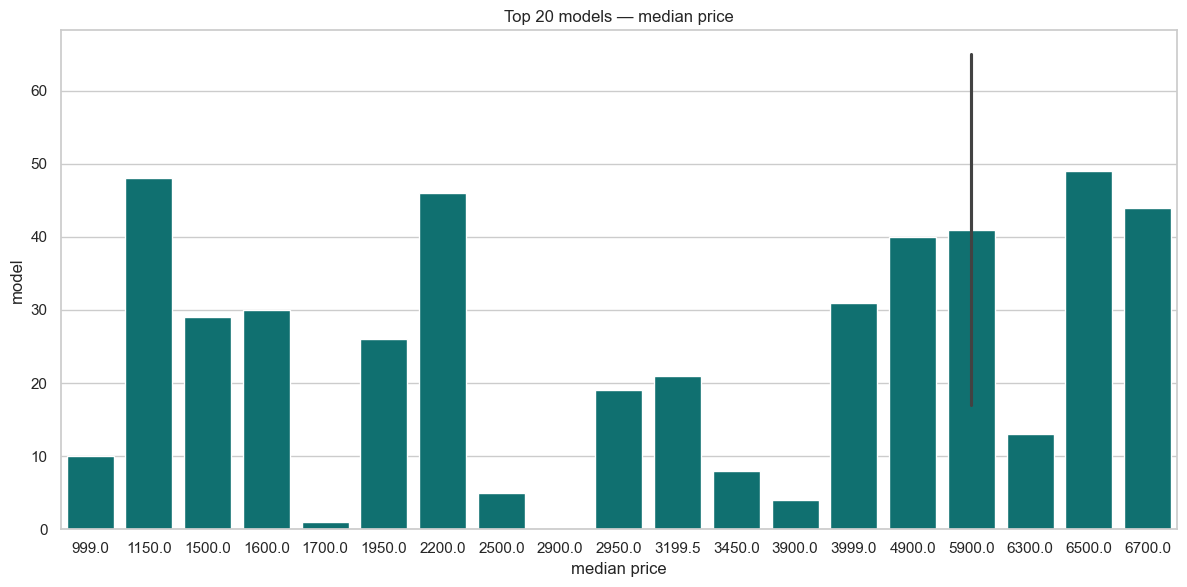

In [21]:
top_models = df["model"].value_counts().head(20).index
model_plot = df[df["model"].isin(top_models)]

fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(data=model_plot, y="model", order=top_models, ax=ax)
ax.set_title("Top 20 models — listing count")
ax.set_ylabel("model")
plt.tight_layout()
fig.savefig(FIG_DIR / "model_distribution_count.png", bbox_inches="tight")
plt.show()

model_median = model_plot.groupby("model", observed=True)["price"].median().reindex(top_models)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(y=model_median.index, x=model_median.values, ax=ax, color="teal")
ax.set_title("Top 20 models — median price")
ax.set_xlabel("median price")
plt.tight_layout()
fig.savefig(FIG_DIR / "model_distribution_median_price.png", bbox_inches="tight")
plt.show()

## 13. Power distribution

`power` (engine power) can contain invalid or extreme values; we inspect the raw distribution and a reasonable clipped range.

In [22]:
df["power"].describe()

count    150000.000000
mean        119.316547
std         177.168419
min           0.000000
25%          75.000000
50%         110.000000
75%         150.000000
max       19312.000000
Name: power, dtype: float64

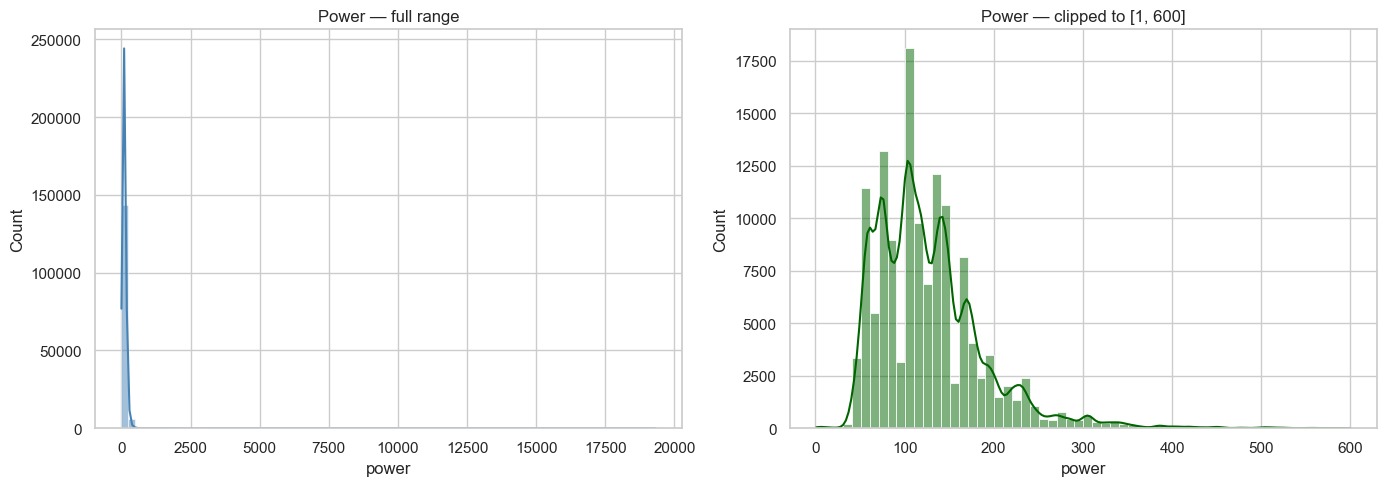

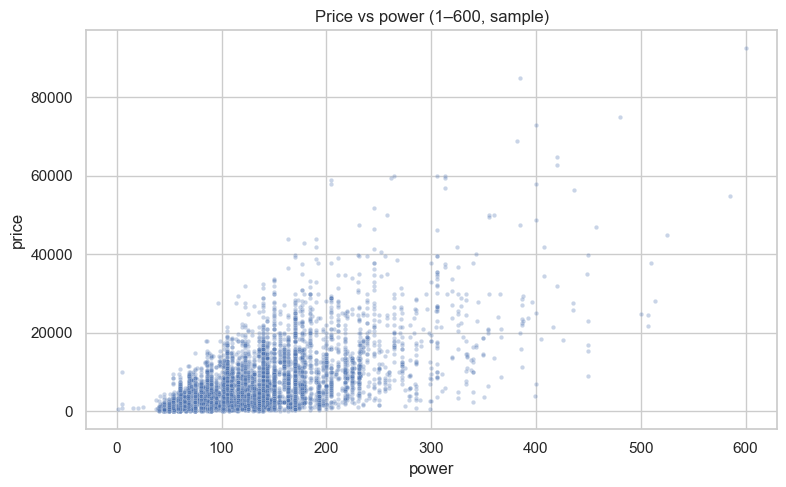

In [23]:
power_valid = df.loc[df["power"].between(1, 600), "power"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["power"].dropna(), bins=80, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Power — full range")
axes[0].set_xlabel("power")

sns.histplot(power_valid, bins=60, kde=True, ax=axes[1], color="darkgreen")
axes[1].set_title("Power — clipped to [1, 600]")
axes[1].set_xlabel("power")
plt.tight_layout()
fig.savefig(FIG_DIR / "power_distribution.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sample_pwr = df[["power", "price"]].dropna().sample(min(8000, len(df)), random_state=RANDOM_STATE)
sample_pwr = sample_pwr[sample_pwr["power"].between(1, 600)]
sns.scatterplot(data=sample_pwr, x="power", y="price", alpha=0.3, s=10, ax=ax)
ax.set_title("Price vs power (1–600, sample)")
plt.tight_layout()
fig.savefig(FIG_DIR / "power_vs_price.png", bbox_inches="tight")
plt.show()

## 14. Outlier identification

We flag outliers using:
- **IQR rule** on `price`, `power`, and `kilometer`
- **Z-score** (|z| > 3) on `price` and anonymized `v_*` features

Domain notes: `power == 0` and very large `power` values are often data errors in this dataset.

In [24]:
def iqr_outlier_mask(series: pd.Series, k: float = 1.5) -> pd.Series:
    """IQR 法标记离群点"""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (series < lower) | (series > upper)


outlier_cols = ["price", "power", "kilometer"]
iqr_flags = pd.DataFrame({col: iqr_outlier_mask(df[col]) for col in outlier_cols})
iqr_summary = pd.DataFrame(
    {
        "iqr_outliers": iqr_flags.sum(),
        "iqr_outlier_pct": (iqr_flags.mean() * 100).round(2),
    }
)
iqr_summary

,iqr_outliers,iqr_outlier_pct
price,10353,6.90
power,4878,3.25
kilometer,25685,17.12


In [25]:
price_z = (df["price"] - df["price"].mean()) / df["price"].std()
price_z_outliers = (price_z.abs() > 3).sum()
print(f"Price |z|>3: {price_z_outliers:,} ({price_z_outliers / len(df) * 100:.2f}%)")

power_zero = (df["power"] == 0).sum()
power_high = (df["power"] > 600).sum()
print(f"power == 0: {power_zero:,}")
print(f"power > 600: {power_high:,}")

Price |z|>3: 2,880 (1.92%)
power == 0: 12,829
power > 600: 143


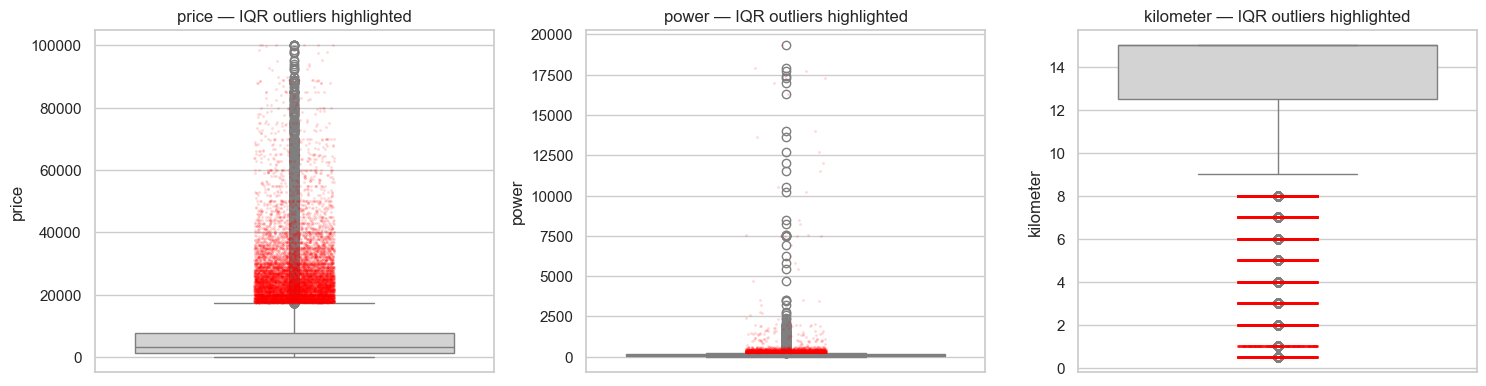

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color="lightgray")
    sns.stripplot(
        y=df.loc[iqr_outlier_mask(df[col]), col],
        ax=ax,
        color="red",
        alpha=0.15,
        size=2,
        jitter=True,
    )
    ax.set_title(f"{col} — IQR outliers highlighted")
plt.tight_layout()
fig.savefig(FIG_DIR / "outliers_iqr_boxplot.png", bbox_inches="tight")
plt.show()

## 15. Correlation heatmap

Pearson correlation among numeric features and `price`. For readability we show the full `v_*` block and a focused heatmap on business numerics + top correlated `v_*` columns.

In [27]:
corr_cols = ["price", "power", "kilometer", "regionCode", "model", "brand"] + v_cols
corr_matrix = df[corr_cols].corr(numeric_only=True)

price_s = corr_matrix["price"].drop("price")
price_corr = price_s.iloc[price_s.abs().argsort()[::-1]]
print("Top correlations with price:")
print(price_corr.head(12).to_string())

Top correlations with price:
v_3         -0.730946
v_12         0.692823
v_8          0.685798
v_0          0.628397
kilometer   -0.440519
v_11        -0.275320
v_10        -0.246175
power        0.219834
v_9         -0.206205
v_5          0.164317
v_4         -0.147085
model        0.136983


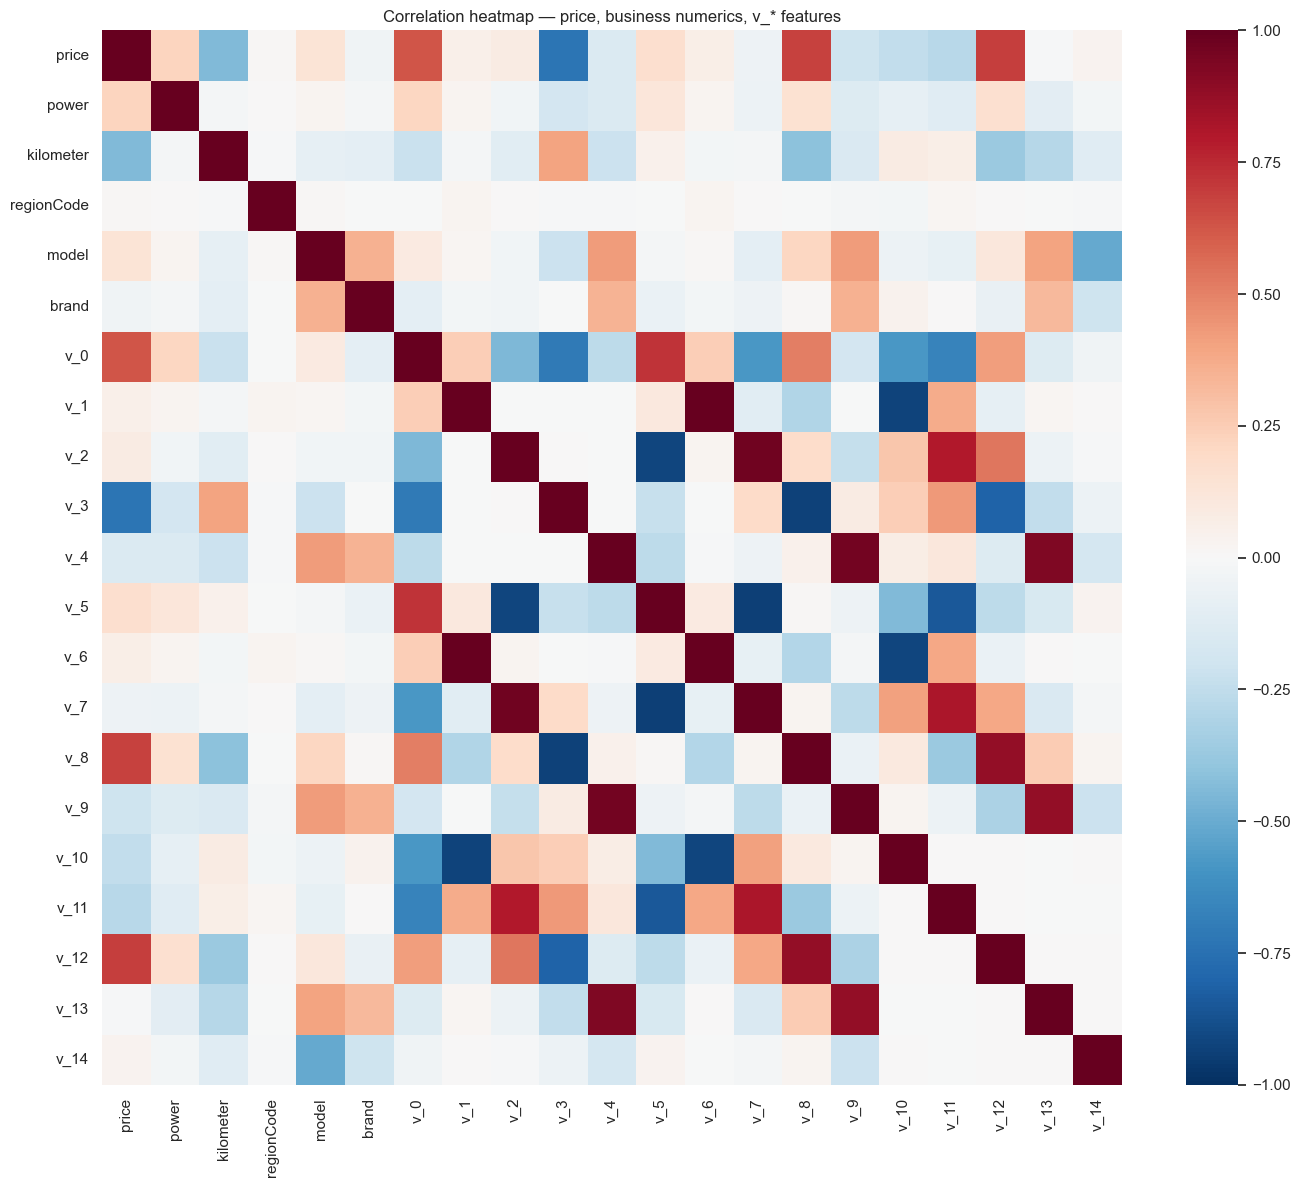

In [28]:
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation heatmap — price, business numerics, v_* features")
plt.tight_layout()
fig.savefig(FIG_DIR / "correlation_heatmap_full.png", bbox_inches="tight")
plt.show()

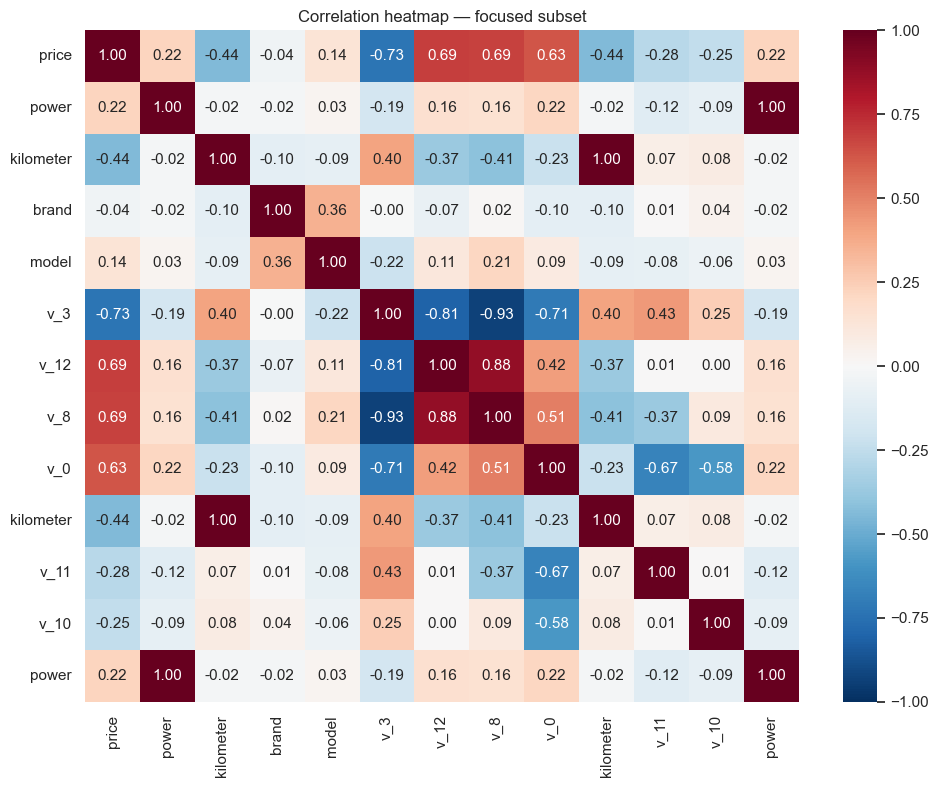

In [29]:
top_v_for_plot = price_corr.head(8).index.tolist()
focused_cols = ["price", "power", "kilometer", "brand", "model"] + top_v_for_plot
corr_focus = df[focused_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_focus,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
)
ax.set_title("Correlation heatmap — focused subset")
plt.tight_layout()
fig.savefig(FIG_DIR / "correlation_heatmap_focused.png", bbox_inches="tight")
plt.show()

## 16. Saved figures

All plots above are written to `reports/figures/`. List generated files:

In [30]:
saved = sorted(FIG_DIR.glob("*.png"))
for p in saved:
    print(p.name)
print(f"\nTotal: {len(saved)} figure(s) in {FIG_DIR}")

brand_distribution.png
categorical_counts.png
categorical_price_boxplot.png
correlation_heatmap_focused.png
correlation_heatmap_full.png
missing_values_bar.png
missing_values_heatmap.png
model_distribution_count.png
model_distribution_median_price.png
numerical_key_distributions.png
numerical_vs_price_scatter.png
outliers_iqr_boxplot.png
power_distribution.png
power_vs_price.png
price_boxplot.png
price_hist_kde.png
price_log_hist_kde.png

Total: 17 figure(s) in reports/figures


## Summary & next steps

| Finding | Implication for modeling |
|--------|---------------------------|
| Right-skewed `price` | Consider `log1p(price)` or robust loss |
| Missing values in `bodyType`, `fuelType`, `gearbox`, `model`, etc. | Impute or use models that handle NA |
| `power` zeros / extremes | Clip or treat as missing |
| Strong `v_*` correlations with `price` | Leverage anonymized features; watch multicollinearity |
| Brand/model imbalance | Stratified validation; target encoding with regularization |

**Suggested follow-up:** feature engineering (vehicle age from `regDate`/`creatDate`), missing-value strategy, and baseline regression with cross-validation.